In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from msi.utils import preprocessing
from msfm.utils import files, cross_statistics
from msfm.utils import power_spectra as ps_utils


In [11]:
class PCAWhiteningLayer:
    """Pure-numpy equivalent of deep_lss.nets.mlp.PCAWhiteningLayer (no TensorFlow required).

    Same algorithm: np.linalg.eigh on the sample covariance, descending sort,
    optional whitening by sqrt(eigval + eps). fit() subsamples to max_samples rows
    just like the original.
    """

    def __init__(self, n_components, whiten=True, eps=1e-8):
        self.n_components = n_components
        self.whiten = whiten
        self.eps = eps
        self.mean_ = None
        self.components_ = None

    def fit(self, x, max_samples=200_000):
        rng = np.random.default_rng(0)
        if x.shape[0] > max_samples:
            idx = rng.choice(x.shape[0], size=max_samples, replace=False)
            x = x[idx]
        x = x.astype(np.float64)
        mean = x.mean(axis=0)
        cov = np.cov(x.T)
        eigvals, eigvecs = np.linalg.eigh(cov)
        # eigh returns ascending order — reverse to descending (matches mlp.py)
        idx = np.argsort(eigvals)[::-1][: self.n_components]
        if self.whiten:
            components = eigvecs[:, idx] / np.sqrt(eigvals[idx] + self.eps)
        else:
            components = eigvecs[:, idx]
        self.mean_ = mean.astype(np.float32)
        self.components_ = components.astype(np.float32)

    def __call__(self, inputs):
        return (inputs - self.mean_) @ self.components_


In [12]:
REPOS   = '/users/athomsen/dlss/repos'
SCRATCH = '/iopsstor/scratch/cscs/athomsen'
VERSION    = 'v16'
SUBVERSION = 'rot_in_place'

msfm_conf = f'{REPOS}/multiprobe-simulation-forward-model/configs/{VERSION}/{SUBVERSION}.yaml'
base_dir  = f'{SCRATCH}/deep_lss/data/{VERSION}/{SUBVERSION}'

dlss_confs = {
    'lensing':    f'{REPOS}/y3-deep-lss/configs/{VERSION}/{SUBVERSION}/lensing/dlss.yaml',
    'clustering': f'{REPOS}/y3-deep-lss/configs/{VERSION}/{SUBVERSION}/clustering/dlss.yaml',
    'combined':   f'{REPOS}/y3-deep-lss/configs/{VERSION}/{SUBVERSION}/combined/dlss.yaml',
}

N_TRACES = 30
SEED = 42
N_PCA_COMPONENTS = None  # None = keep all components; set e.g. 128 to truncate


In [13]:
_PROBE_FLAGS = {
    'lensing':    dict(with_lensing=True,  with_clustering=False, with_cross_z=True, with_cross_probe=False),
    'clustering': dict(with_lensing=False, with_clustering=True,  with_cross_z=True, with_cross_probe=False),
    'combined':   dict(with_lensing=True,  with_clustering=True,  with_cross_z=True, with_cross_probe=True),
}


def load_probe_data(probe):
    out_dict = preprocessing.get_binned_power_spectra(
        base_dir=base_dir,
        msfm_conf=msfm_conf,
        dlss_conf=dlss_confs[probe],
        apply_log=False,
        with_gaussian_noise=True,
        **_PROBE_FLAGS[probe],
    )
    cls_raw_train = out_dict['grid/cls_raw/train']   # (n_train, n_dims), scale-cut, no noise
    noise_pool    = out_dict['noise/cls']            # (n_noise, n_dims), sigma-scaled, or None

    conf    = files.load_config(msfm_conf)
    ps_conf = conf['analysis']['power_spectra']
    bins    = ps_utils.get_cl_bins(ps_conf['l_min'], ps_conf['l_max'], ps_conf['n_bins'])
    ell_centers = np.sqrt(bins[:-1] * bins[1:])

    n_z_lensing    = len(conf['survey']['metacal']['z_bins'])
    n_z_clustering = len(conf['survey']['maglim']['z_bins'])
    _, pair_names = cross_statistics.get_cross_bin_indices(
        n_z_lensing=n_z_lensing, n_z_clustering=n_z_clustering, **_PROBE_FLAGS[probe]
    )

    return cls_raw_train, noise_pool, ell_centers, pair_names


In [14]:
def add_noise(cls, noise_pool, rng):
    if noise_pool is None:
        return cls
    i = rng.integers(0, noise_pool.shape[0], cls.shape[0])
    return cls + noise_pool[i]


def get_eigenspectrum(log_cls):
    """Replicate PCAWhiteningLayer.fit covariance estimation to get sorted eigenvalues."""
    x = log_cls.astype(np.float64)
    if x.shape[0] > 200_000:
        idx = np.random.default_rng(0).choice(x.shape[0], size=200_000, replace=False)
        x = x[idx]
    cov     = np.cov(x.T)
    eigvals = np.linalg.eigh(cov)[0][::-1]  # descending
    return eigvals, eigvals / eigvals.sum()


In [15]:
def _add_pair_labels(ax, n_dims, n_ell, pair_names):
    """Vertical pair-boundary lines + pair labels on a secondary top x-axis."""
    n_pairs = n_dims // n_ell
    for k in range(1, n_pairs):
        ax.axvline(k * n_ell - 0.5, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax_top = ax.twiny()
    ax_top.set_xlim(0, n_dims)
    ax_top.set_xticks([(k + 0.5) * n_ell for k in range(n_pairs)])
    ax_top.set_xticklabels(pair_names, fontsize=7, color='dimgray', rotation=45, ha='left')
    ax_top.tick_params(axis='x', which='both', length=0, pad=2)
    ax_top.spines['top'].set_visible(False)
    ax_top.yaxis.set_visible(False)


def plot_probe(probe, cls_raw_train, noise_pool, ell_centers, pair_names):
    n_pairs  = len(pair_names)
    n_ell    = len(ell_centers)
    n_dims   = cls_raw_train.shape[1]
    n_comps  = N_PCA_COMPONENTS if N_PCA_COMPONENTS is not None else n_dims
    x_cl     = np.arange(n_dims)
    x_pc     = np.arange(n_comps)
    ell_tile = np.tile(ell_centers, n_pairs)

    # N_TRACES signal realisations for display
    i_pick     = np.random.default_rng(SEED).integers(0, cls_raw_train.shape[0], N_TRACES)
    cls_traces = cls_raw_train[i_pick]

    # add a noise draw for the display traces
    cls_noisy     = add_noise(cls_traces, noise_pool, np.random.default_rng(SEED + 1))
    log_cls_noisy = np.nan_to_num(np.log(np.abs(cls_noisy)))

    # full training set with noise for PCA fitting
    cls_train_noisy = add_noise(cls_raw_train, noise_pool, np.random.default_rng(SEED + 2))
    log_cls_train   = np.nan_to_num(np.log(np.abs(cls_train_noisy)))

    # fit PCA layers — same algorithm as PCAWhiteningLayer in deep_lss/nets/mlp.py
    pca_plain = PCAWhiteningLayer(n_components=n_comps, whiten=False)
    pca_plain.fit(log_cls_train)
    pca_white = PCAWhiteningLayer(n_components=n_comps, whiten=True)
    pca_white.fit(log_cls_train)

    # project display traces into PC space (same as PCAWhiteningLayer.call)
    scores_plain = (log_cls_noisy - pca_plain.mean_) @ pca_plain.components_
    scores_white = (log_cls_noisy - pca_white.mean_) @ pca_white.components_

    eigvals, explained = get_eigenspectrum(log_cls_train)

    kw_thin = dict(alpha=0.35, lw=0.8, color='tab:blue')
    kw_med  = dict(lw=2.0, color='k', label='median')

    fig, axes = plt.subplots(
        7, 1, figsize=(16, 28),
        gridspec_kw={'hspace': 0.55, 'height_ratios': [3, 3, 3, 3, 2, 3, 2]},
    )

    # --- panel 0: raw Cl + noise (log y) ---
    ax = axes[0]
    ax.plot(x_cl, cls_noisy.T, **kw_thin)
    ax.plot(x_cl, np.median(cls_noisy, axis=0), **kw_med)
    ax.set_yscale('log')
    ax.set_xlim(0, n_dims)
    ax.set(ylabel=r'$C_\ell$', title=f'{probe} -- raw Cl + noise')
    _add_pair_labels(ax, n_dims, n_ell, pair_names)

    # --- panel 1: ell * Cl + noise (linear) ---
    ax = axes[1]
    lcl = cls_noisy * ell_tile
    ax.plot(x_cl, lcl.T, **kw_thin)
    ax.plot(x_cl, np.median(lcl, axis=0), **kw_med)
    ax.set_xlim(0, n_dims)
    ax.set(ylabel=r'$\ell\,C_\ell$', title=f'{probe} -- ell * Cl + noise')
    _add_pair_labels(ax, n_dims, n_ell, pair_names)

    # --- panel 2: log|Cl + noise|  (default MLP input, no PCA) ---
    ax = axes[2]
    ax.plot(x_cl, log_cls_noisy.T, **kw_thin)
    ax.plot(x_cl, np.median(log_cls_noisy, axis=0), **kw_med)
    ax.set_xlim(0, n_dims)
    ax.set(ylabel=r'$\log|C_\ell|$', title=f'{probe} -- log|Cl + noise|  (default MLP input)')
    _add_pair_labels(ax, n_dims, n_ell, pair_names)

    # --- panel 3: PCA scores, whiten=False ---
    ax = axes[3]
    ax.plot(x_pc, scores_plain.T, **kw_thin)
    ax.plot(x_pc, np.median(scores_plain, axis=0), **kw_med)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlim(0, n_comps)
    ax.set(ylabel='score', title=f'{probe} -- log|Cl| -> PCA (whiten=False), {n_comps} components')

    # --- panel 4: eigenspectrum ---
    ax  = axes[4]
    ev  = eigvals[:n_comps]
    ax.bar(x_pc, ev / ev.max(), alpha=0.6, color='tab:blue', width=1.0)
    ax2 = ax.twinx()
    cumvar = np.cumsum(explained[:n_comps])
    ax2.plot(x_pc, cumvar, color='tab:orange', lw=1.5, label='cumul. var.')
    ax2.axhline(0.99, color='tab:orange', lw=0.8, ls='--', alpha=0.6)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('cumulative variance')
    ax2.legend(fontsize=8, loc='center right')
    ax.set_xlim(0, n_comps)
    ax.set(ylabel='rel. eigenvalue', xlabel='PC index',
           title=f'{probe} -- eigenspectrum  (cum. var. at {n_comps} PCs: {cumvar[-1]:.4f})')

    # --- panel 5: PCA scores, whiten=True ---
    ax = axes[5]
    ax.plot(x_pc, scores_white.T, **kw_thin)
    ax.plot(x_pc, np.median(scores_white, axis=0), **kw_med)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlim(0, n_comps)
    ax.set(ylabel='score', title=f'{probe} -- log|Cl| -> PCA (whiten=True), {n_comps} components')

    # --- panel 6: std of whitened scores per PC ---
    ax = axes[6]
    ax.bar(x_pc, np.std(scores_white, axis=0), alpha=0.6, color='tab:purple', width=1.0)
    ax.axhline(1.0, color='k', lw=1.0, ls='--', label='std=1')
    ax.set_xlim(0, n_comps)
    ax.set(ylabel='std of whitened scores', xlabel='PC index',
           title=f'{probe} -- per-PC std of whitened scores  ({N_TRACES} display realisations)')
    ax.legend(fontsize=8)

    fig.suptitle(f'Cls preprocessing -- {probe}  ({VERSION}/{SUBVERSION})', fontsize=14, y=1.002)
    plt.tight_layout()
    plt.show()


## Lensing

26-05-22 17:54:00 configuratio INF   Loaded the config 
26-05-22 17:54:00 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 130.2, 88.9, 68.1, 57.0] from the dlss config 
26-05-22 17:54:00 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.85135, 0.34375, 0.25989, 0.24127] from the dlss config 
26-05-22 17:54:00 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-05-22 17:54:00 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
26-05-22 17:54:00 preprocessin INF   Using n_bins = 33 from the msfm config 
26-05-22 17:54:00 preprocessin INF   Loading the pre-binned Cls 
26-05-22 17:54:00 input_output INF   Loading summaries from /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place 
26-05-22 17:54:00 input_output INF   Array shapes: 
26-05-22 17:54:00 input_output INF   fiduc

/tmp/ipykernel_139566/1034660796.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


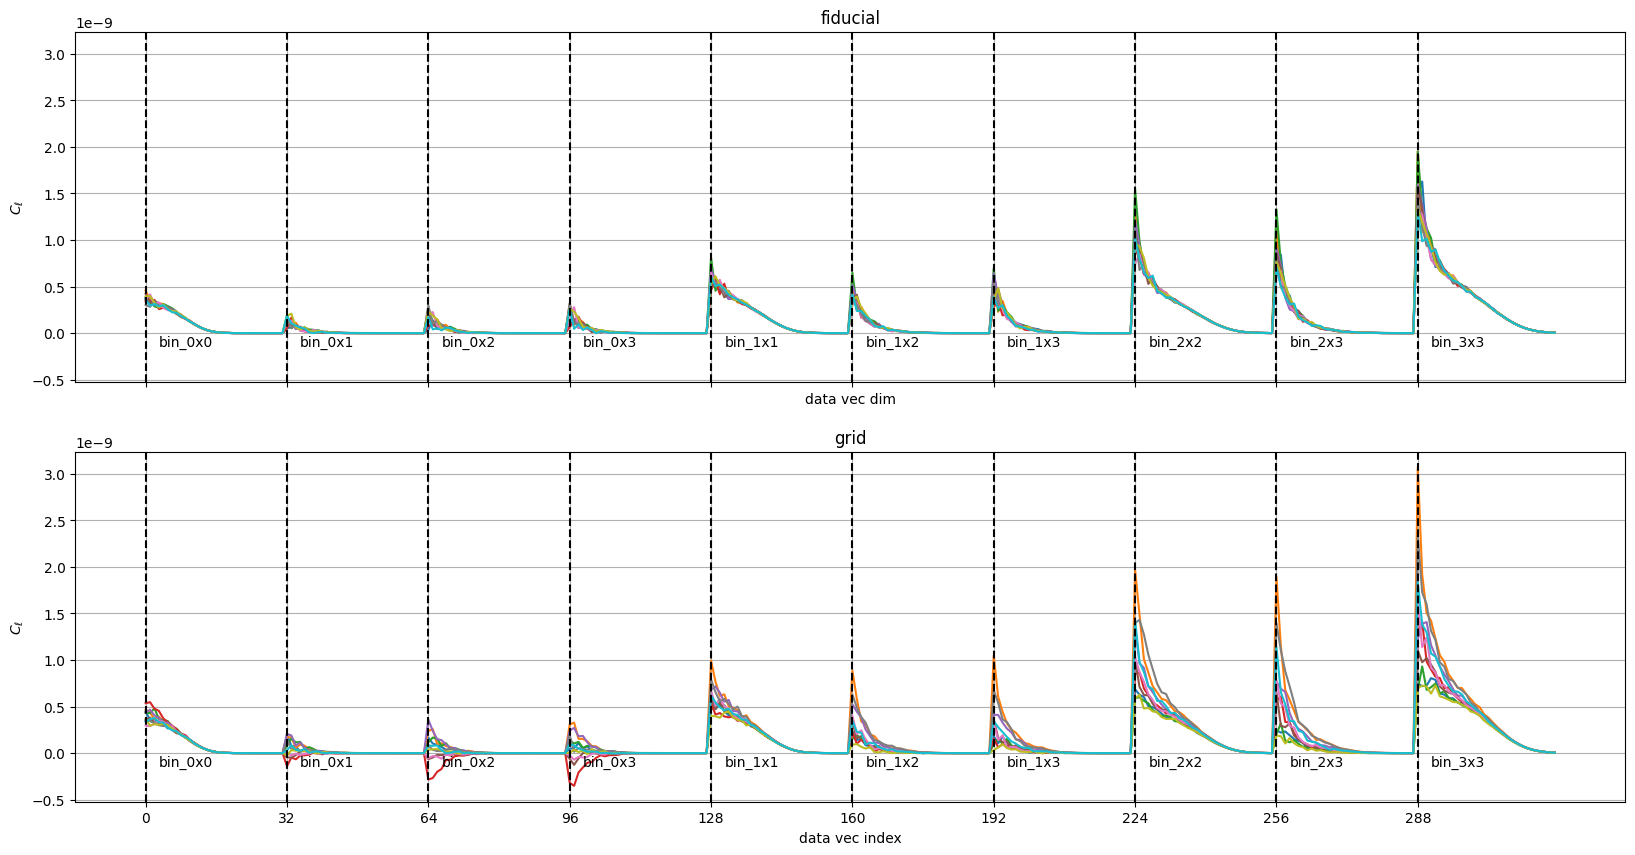

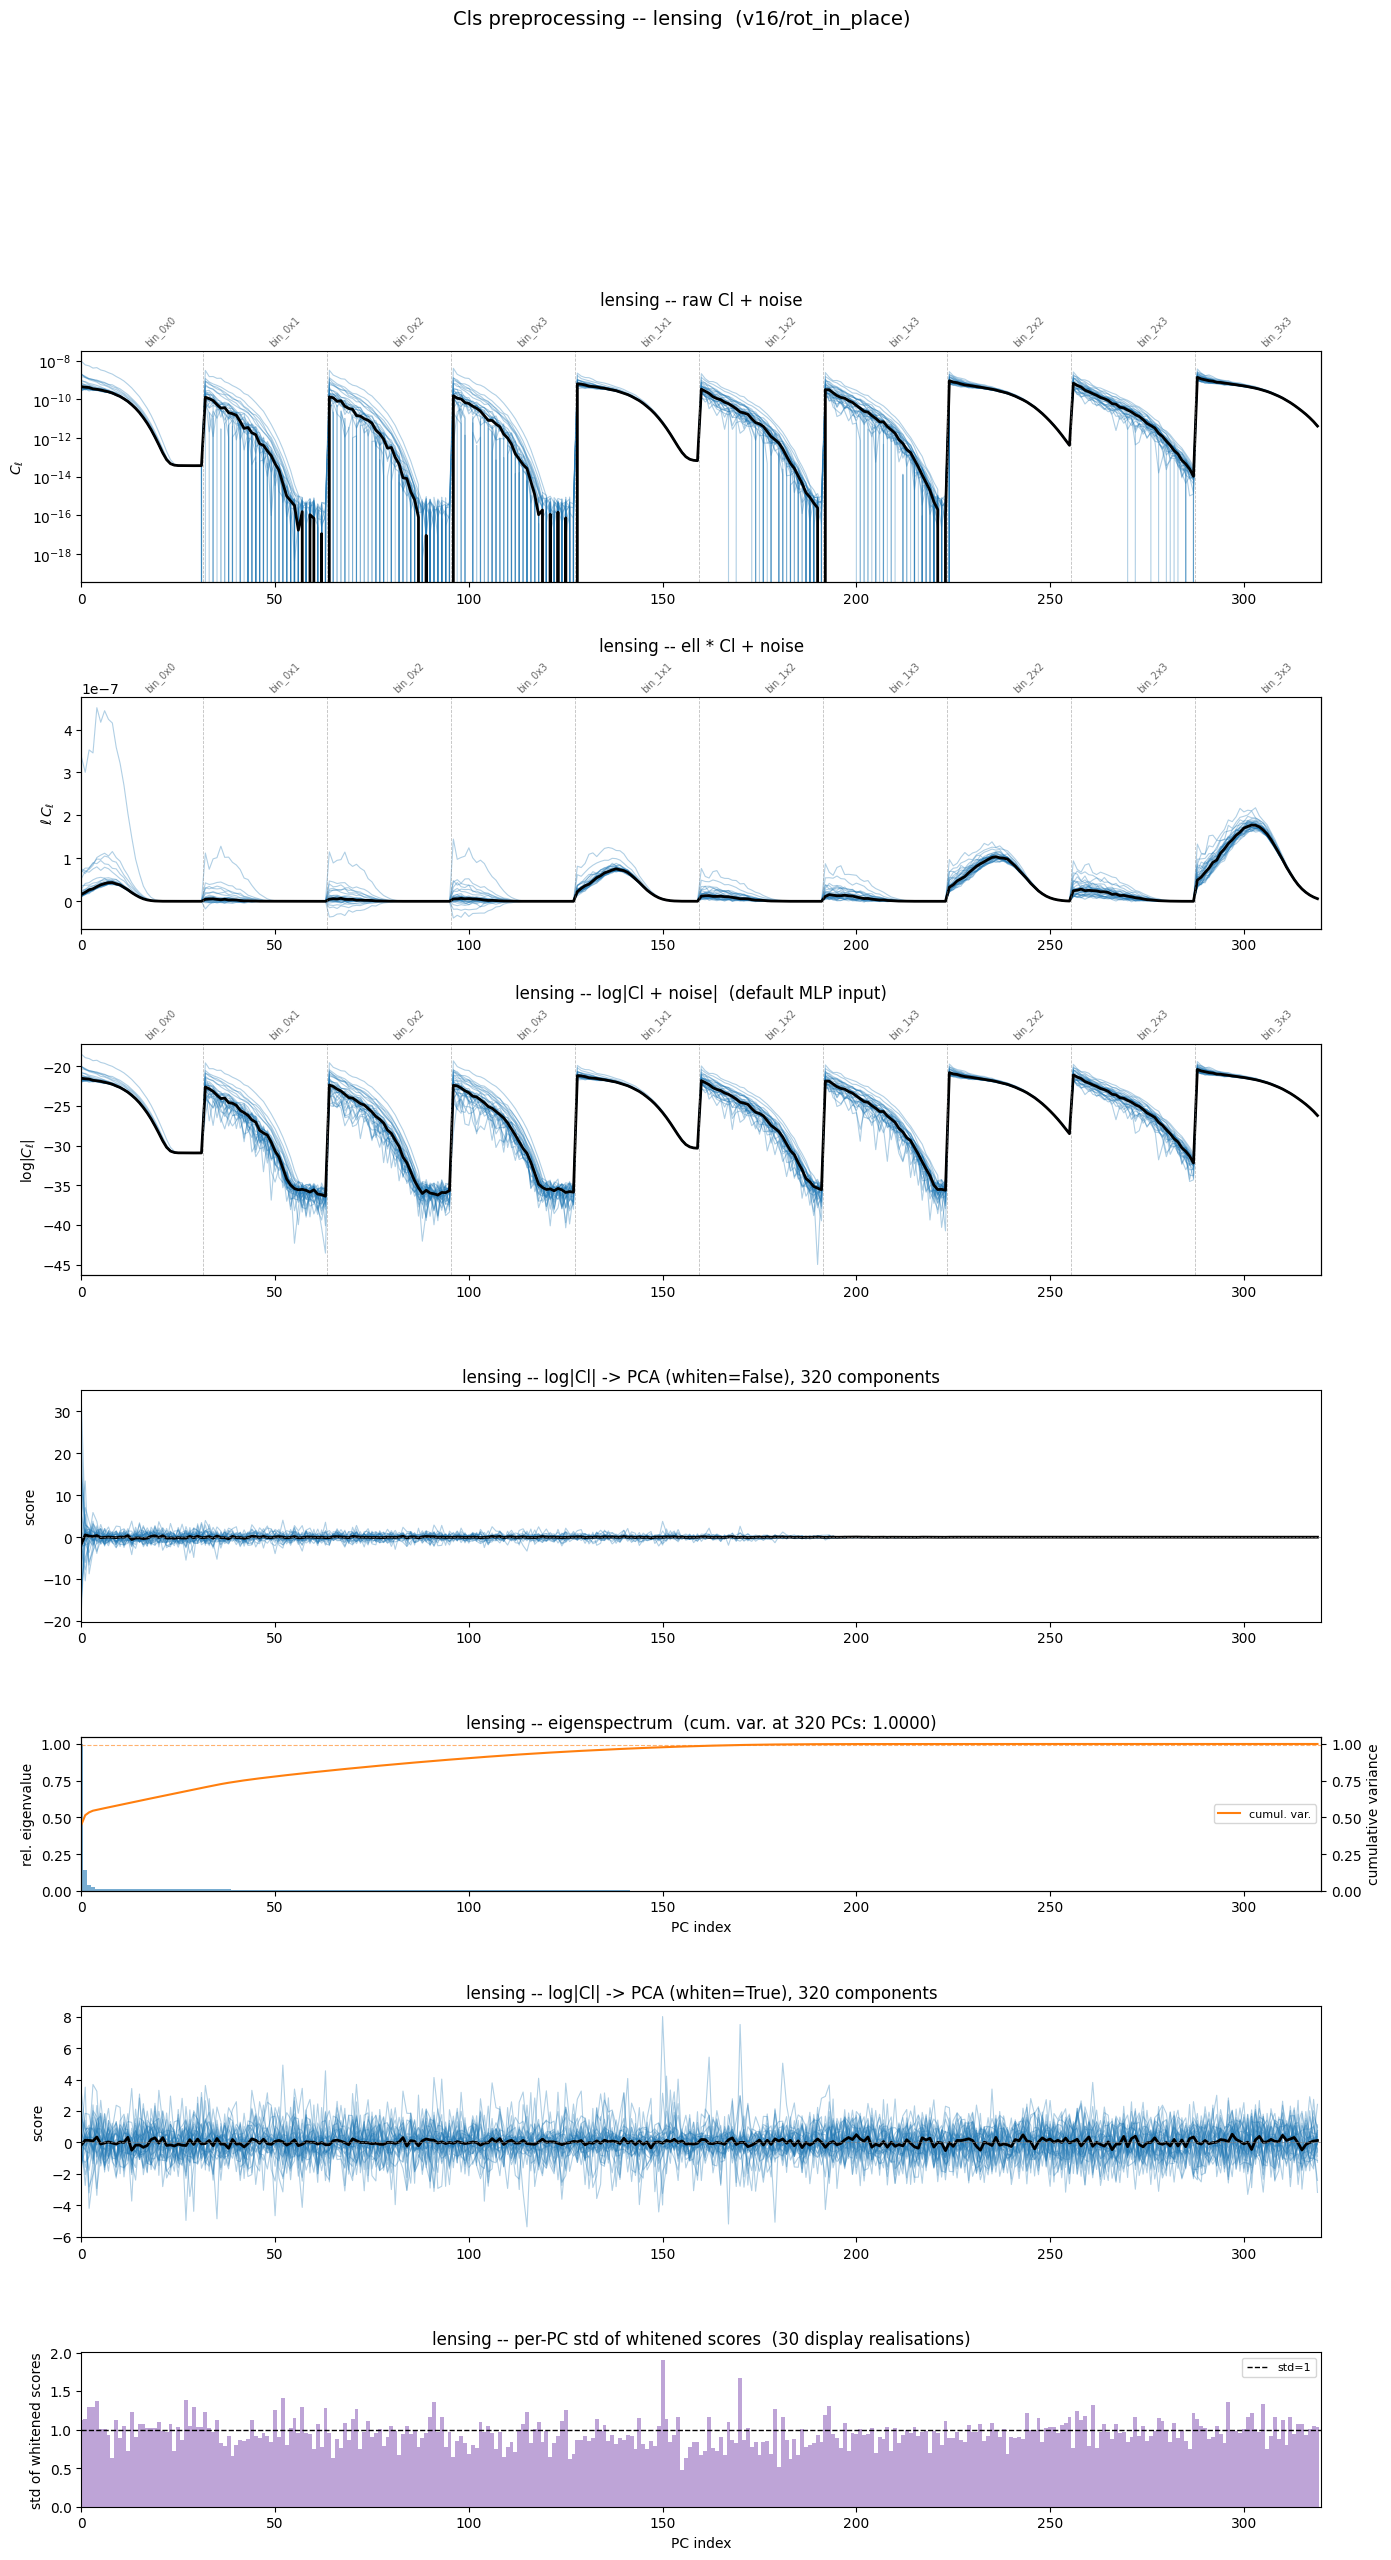

In [16]:
cls_raw, noise_pool, ell_centers, pair_names = load_probe_data('lensing')
plot_probe('lensing', cls_raw, noise_pool, ell_centers, pair_names)


## Clustering

26-05-22 17:54:46 configuratio INF   Loaded the config 
26-05-22 17:54:46 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 130.2, 88.9, 68.1, 57.0] from the dlss config 
26-05-22 17:54:46 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.85135, 0.34375, 0.25989, 0.24127] from the dlss config 
26-05-22 17:54:46 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-05-22 17:54:46 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
26-05-22 17:54:46 preprocessin INF   Using n_bins = 33 from the msfm config 
26-05-22 17:54:46 preprocessin INF   Loading the pre-binned Cls 
26-05-22 17:54:46 input_output INF   Loading summaries from /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place 
26-05-22 17:54:46 input_output INF   Array shapes: 
26-05-22 17:54:46 input_output INF   fiduc

/tmp/ipykernel_139566/1034660796.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


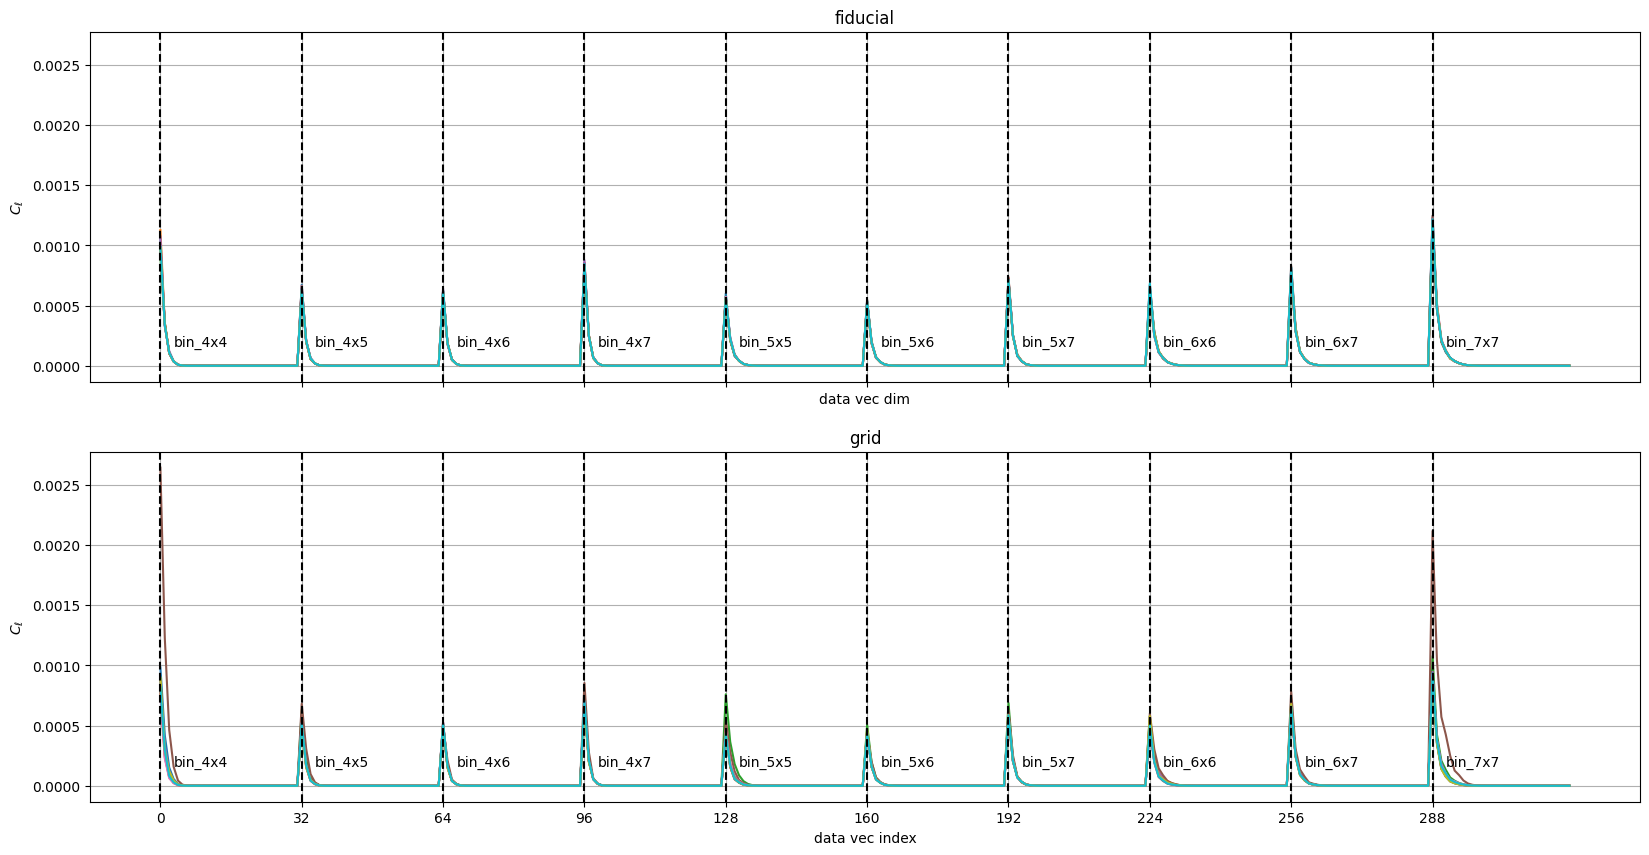

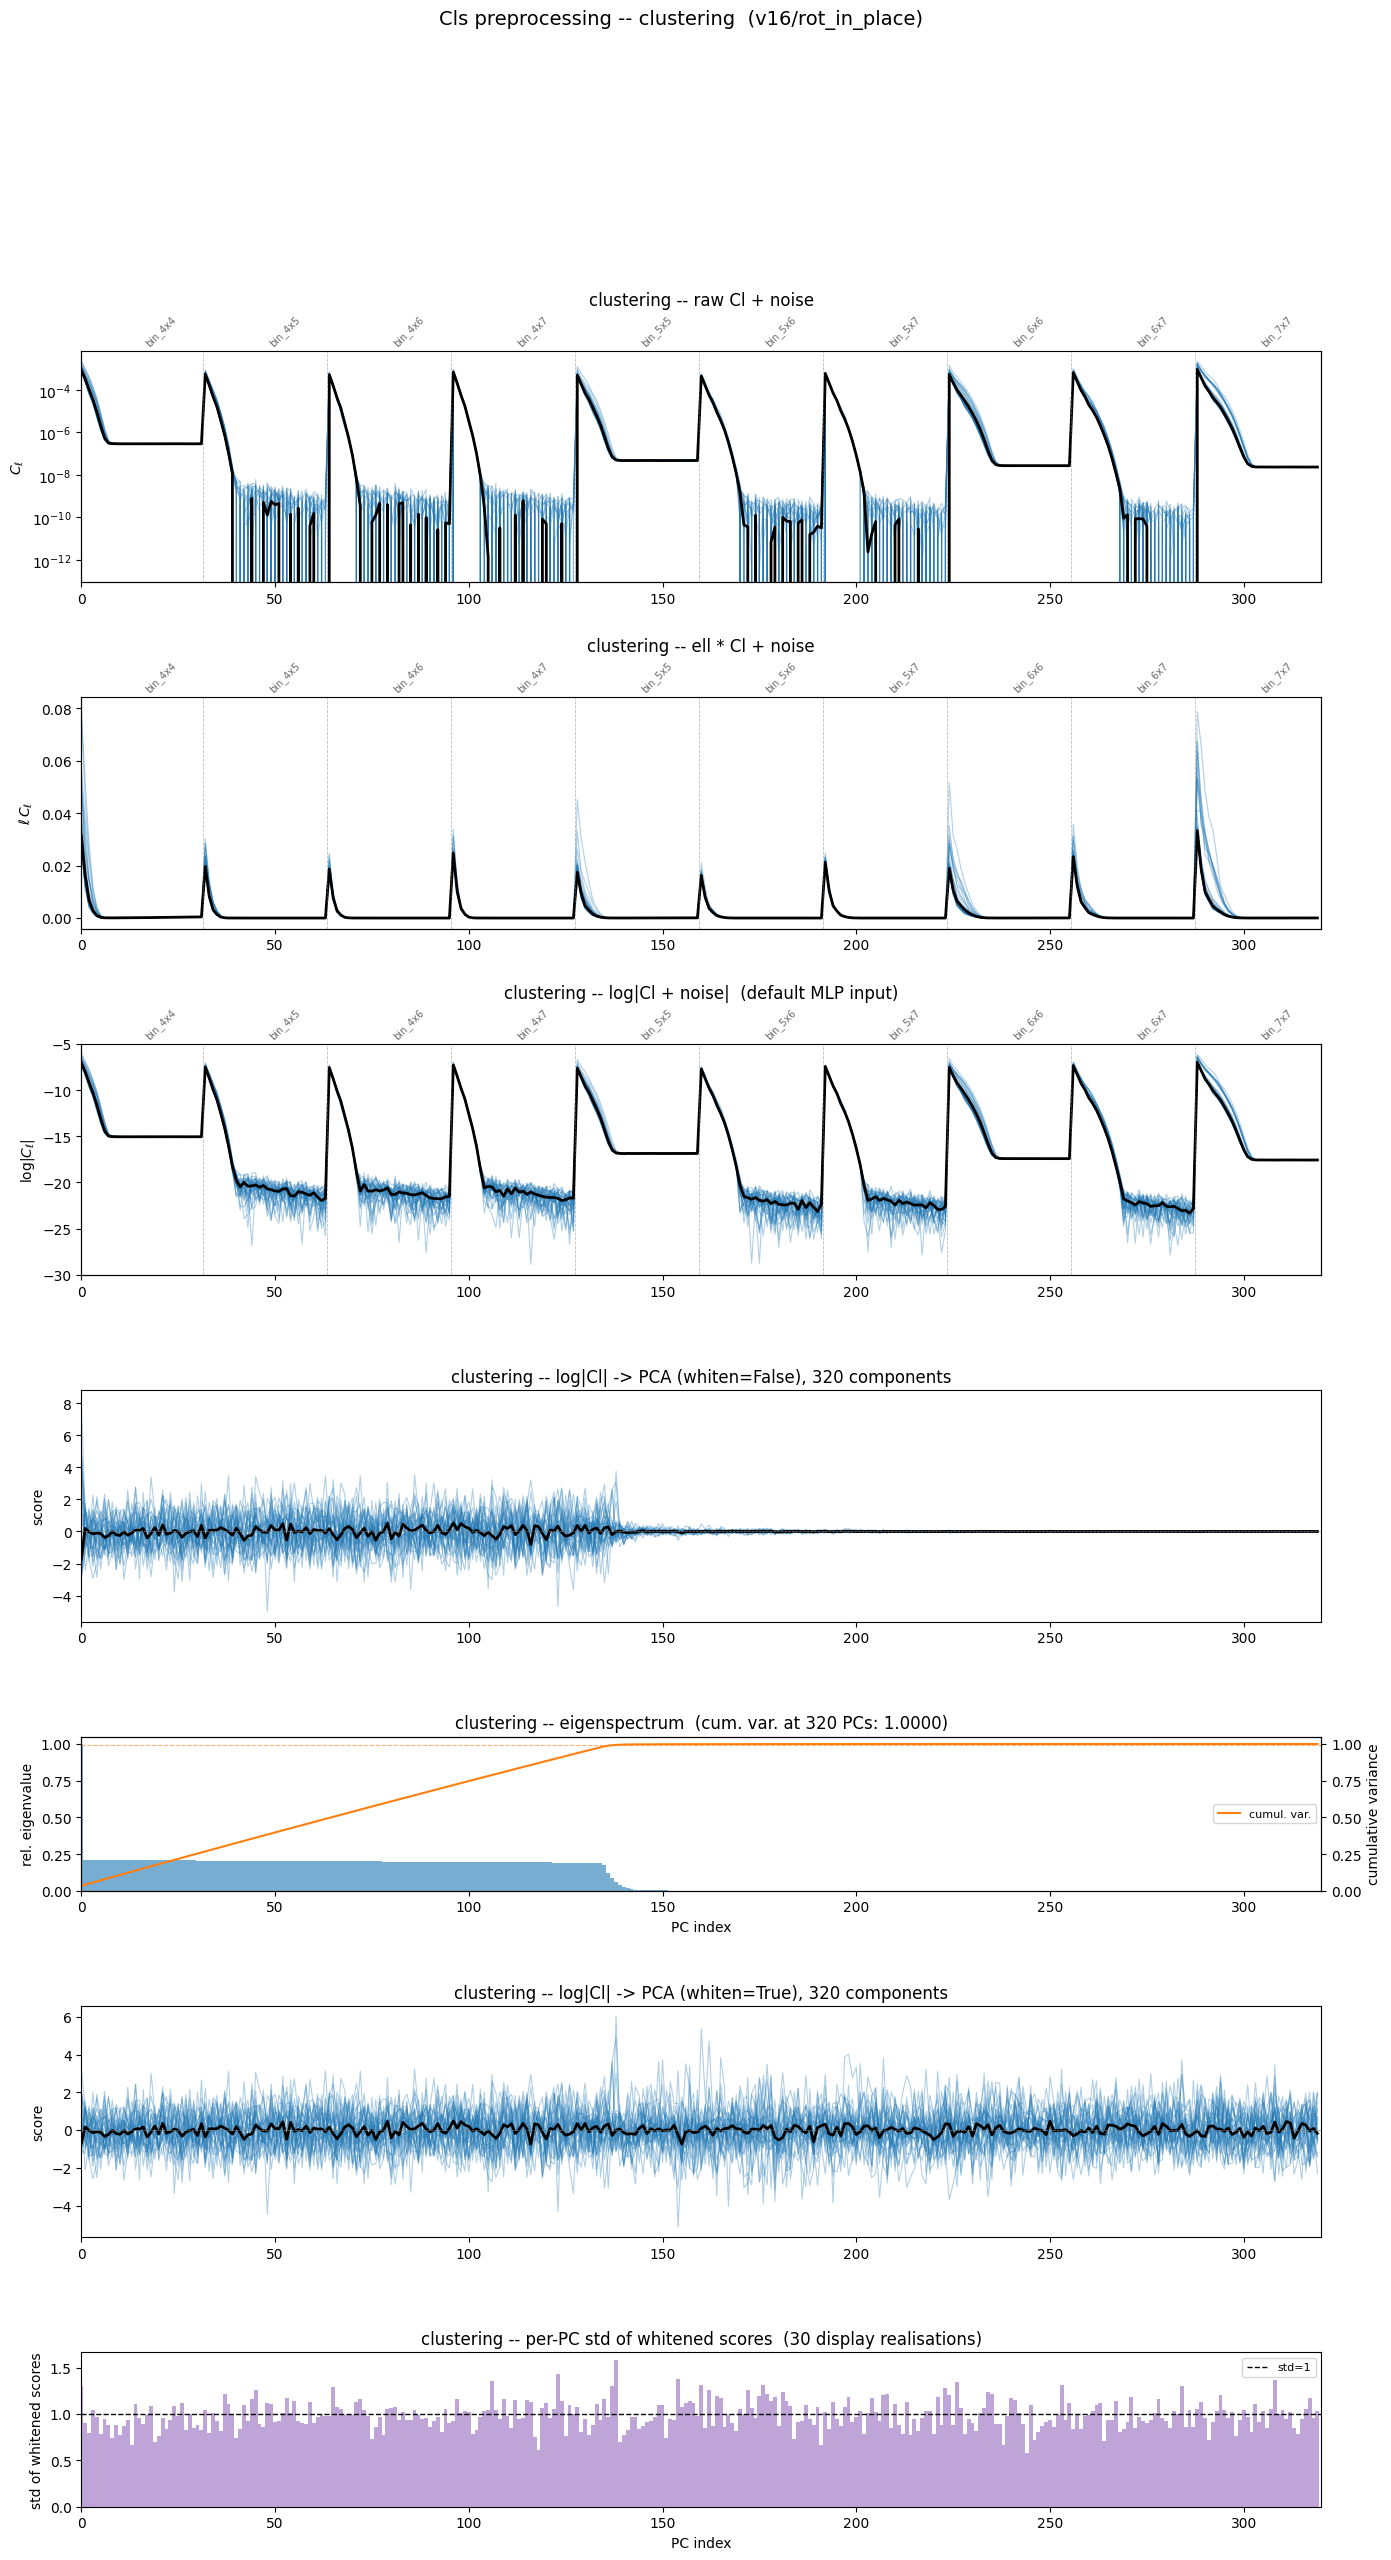

In [17]:
cls_raw, noise_pool, ell_centers, pair_names = load_probe_data('clustering')
plot_probe('clustering', cls_raw, noise_pool, ell_centers, pair_names)


## Combined

26-05-22 17:55:29 configuratio INF   Loaded the config 
26-05-22 17:55:29 preprocessin INF   Using theta_fwhm = [29.5, 20.1, 15.0, 12.6, 130.2, 88.9, 68.1, 57.0] from the dlss config 
26-05-22 17:55:29 preprocessin INF   Using white_noise_sigma = [0.00030275, 0.00040448, 0.00048782, 0.00052049, 0.85135, 0.34375, 0.25989, 0.24127] from the dlss config 
26-05-22 17:55:29 preprocessin INF   Using l_maxs = [366.10169492 537.31343284 720.         857.14285714  82.94930876
 121.4848144  158.59030837 189.47368421] from the dlss config 
26-05-22 17:55:29 preprocessin INF   Using l_mins = [0. 0. 0. 0. 0. 0. 0. 0.] by default (no smoothing) 
26-05-22 17:55:29 preprocessin INF   Using n_bins = 33 from the msfm config 
26-05-22 17:55:29 preprocessin INF   Loading the pre-binned Cls 
26-05-22 17:55:29 input_output INF   Loading summaries from /iopsstor/scratch/cscs/athomsen/deep_lss/data/v16/rot_in_place 
26-05-22 17:55:29 input_output INF   Array shapes: 
26-05-22 17:55:29 input_output INF   fiduc

/tmp/ipykernel_139566/1034660796.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


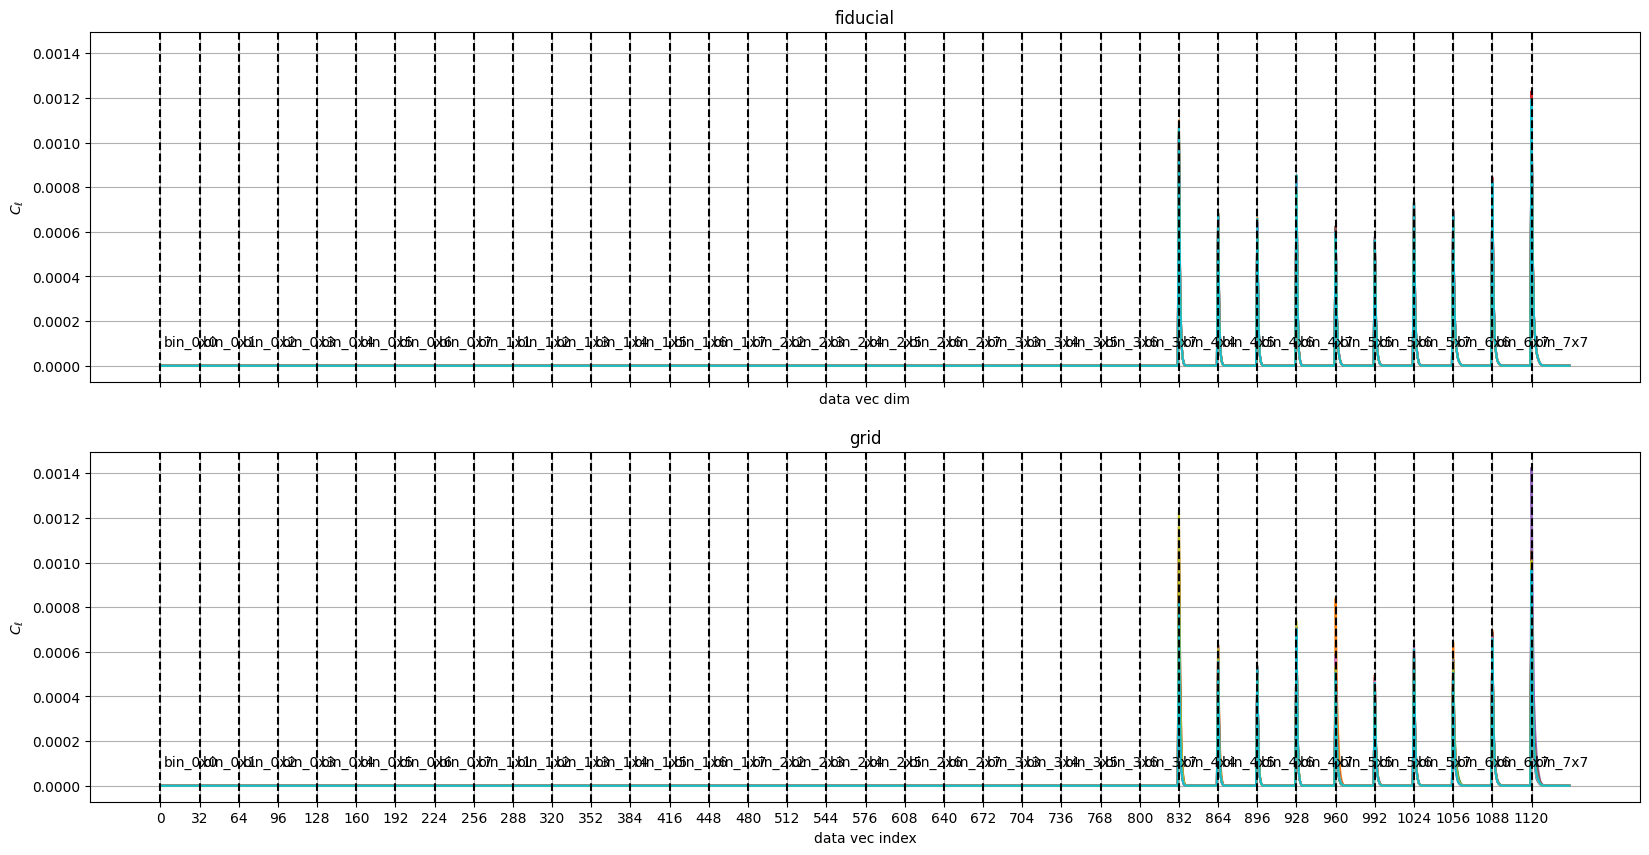

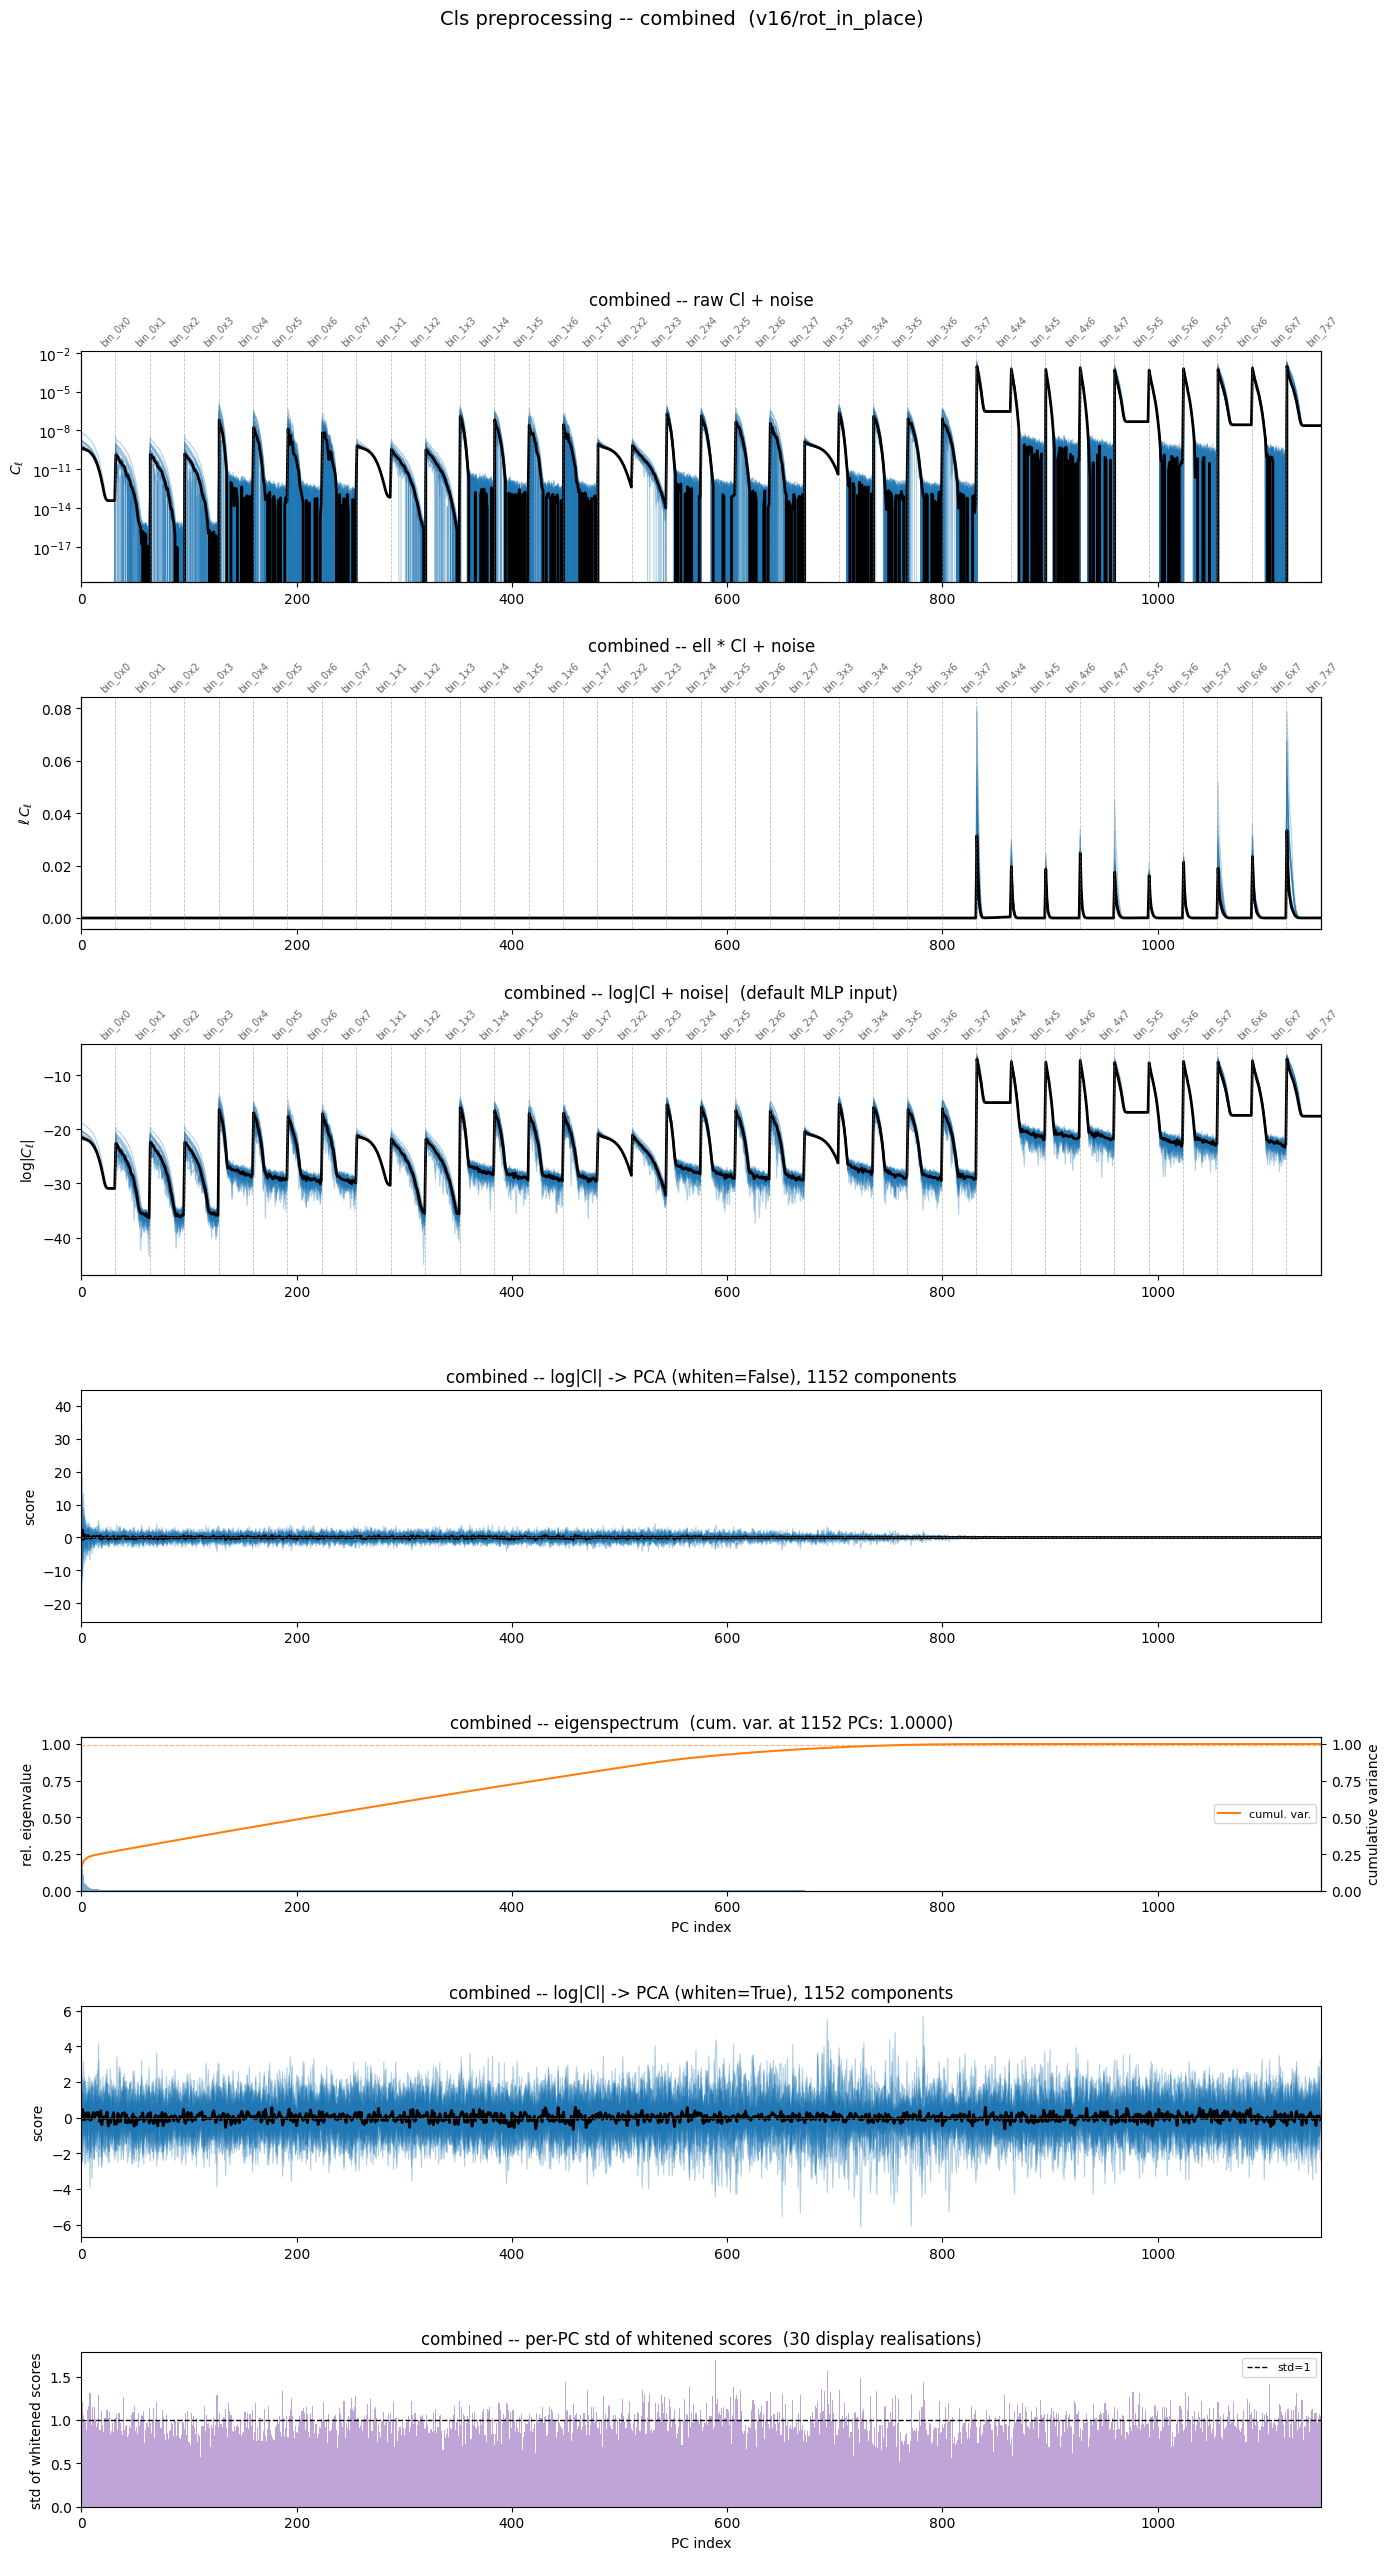

In [18]:
cls_raw, noise_pool, ell_centers, pair_names = load_probe_data('combined')
plot_probe('combined', cls_raw, noise_pool, ell_centers, pair_names)
